# Notebook 16 — Deployment Readiness & Production Monitoring

---

## Objective

This notebook evaluates the machine learning model from a deployment perspective.

The objective is not to improve model accuracy, but to determine whether the trained anomaly detection model is reliable enough for production environments such as Industrial Water Treatment Systems.

---

## In this notebook

The following analyses are performed:

- Load deployment prediction results
- Validate prediction confidence
- Analyze probability distribution
- Evaluate confidence levels
- Investigate prediction reliability
- Assess production readiness
- Generate deployment statistics
- Produce deployment-ready visualizations
- Export deployment summary

---

## Industrial Perspective

In industrial monitoring systems, prediction confidence is often as important as prediction accuracy.

A reliable anomaly detection model should:

- Detect abnormal operating conditions
- Produce stable probability estimates
- Minimize uncertain predictions
- Support operator decision making
- Reduce unnecessary alarms
- Increase trust for deployment

---

## Expected Outputs

This notebook produces:

- Deployment confidence analysis
- Prediction probability distribution
- Confidence level statistics
- Production readiness report
- Deployment visualizations
- Summary tables for industrial reporting

---

## Project Pipeline

Notebook 01 → Data Understanding

Notebook 02 → Data Cleaning

Notebook 03 → Exploratory Data Analysis

Notebook 04 → Feature Engineering

Notebook 05 → Data Preparation

Notebook 06 → Feature Importance

Notebook 07 → Baseline Models

Notebook 08 → Advanced Models

Notebook 09 → Model Benchmark

Notebook 10 → Final Model Training

Notebook 11 → Explainable AI (SHAP)

Notebook 12 → Error Analysis

Notebook 13 → Industrial Performance Evaluation

Notebook 14 → Business & Risk Analysis

Notebook 15 → Model Validation

**Notebook 16 → Deployment Readiness (Current Notebook)**

---

## Author

Hamid Saeli

Machine Learning Engineer

Industrial AI • Predictive Maintenance • Explainable AI

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd


import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

PROJECT_ROOT = Path.cwd().parent

RESULT_PATH = PROJECT_ROOT / "results"

FIGURE_PATH = RESULT_PATH

FIGURE_PATH.mkdir(exist_ok=True)

In [2]:
deployment = pd.read_csv(
    RESULT_PATH/"predictions.csv"
)

deployment.head()

,FIT101,LIT101,MV101,P101,P102,AIT201,AIT202,AIT203,FIT201,MV201,...,PIT501,PIT502,PIT503,FIT601,P601,P602,P603,True,Prediction,Probability
0,0.695766,-0.602819,0.335952,0.606750,-0.046608,-0.248022,-0.785361,-0.092905,0.599198,0.321655,...,0.263217,-0.407415,0.291049,-0.099023,0.0,-0.091453,0.0,0,0,0.000000
1,-1.565178,1.075201,0.335952,0.606750,-0.046608,-0.248022,-0.579222,-0.145340,0.619757,0.321655,...,0.205477,-0.140592,0.214762,-0.099023,0.0,-0.091453,0.0,0,0,0.000000
2,0.571699,-0.503367,0.335952,0.606750,-0.046608,2.225950,-0.204925,-0.122035,0.609123,0.321655,...,0.121798,-0.514144,0.101149,-0.099023,0.0,-0.091453,0.0,0,0,0.030762
3,0.690770,-0.803625,0.335952,0.606750,-0.046608,-0.270778,0.999344,-0.385377,0.599789,0.321655,...,0.067406,-0.780966,0.032440,-0.099023,0.0,-0.091453,0.0,0,0,0.030891
4,-1.565178,1.775168,-2.880775,-1.648125,-0.046608,-0.276842,1.313974,0.306767,-1.651437,-3.020295,...,-6.145809,-3.769375,-6.142788,-0.099023,0.0,-0.091453,0.0,1,1,1.000000


In [3]:
deployment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 288344 entries, 0 to 288343
Data columns (total 54 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   FIT101       288344 non-null  float64
 1   LIT101       288344 non-null  float64
 2   MV101        288344 non-null  float64
 3   P101         288344 non-null  float64
 4   P102         288344 non-null  float64
 5   AIT201       288344 non-null  float64
 6   AIT202       288344 non-null  float64
 7   AIT203       288344 non-null  float64
 8   FIT201       288344 non-null  float64
 9   MV201        288344 non-null  float64
 10  P201         288344 non-null  float64
 11  P202         288344 non-null  float64
 12  P203         288344 non-null  float64
 13  P204         288344 non-null  float64
 14  P205         288344 non-null  float64
 15  P206         288344 non-null  float64
 16  DPIT301      288344 non-null  float64
 17  FIT301       288344 non-null  float64
 18  LIT301       288344 non-

In [4]:
deployment.describe()

,FIT101,LIT101,MV101,P101,P102,AIT201,AIT202,AIT203,FIT201,MV201,...,PIT501,PIT502,PIT503,FIT601,P601,P602,P603,True,Prediction,Probability
count,288344.000000,288344.000000,288344.000000,288344.000000,288344.000000,288344.000000,288344.000000,288344.000000,288344.000000,288344.000000,...,288344.000000,288344.000000,288344.000000,288344.000000,288344.0,288344.000000,288344.0,288344.000000,288344.000000,288344.000000
mean,-0.000348,-0.001682,-0.001267,-0.001058,-0.001193,0.002715,-0.000652,-0.003630,-0.000928,0.001790,...,-0.001422,-0.000478,-0.001473,-0.001332,0.0,0.000130,0.0,0.037885,0.038662,0.049018
std,1.000158,1.000287,1.003201,1.000552,0.987146,1.003118,1.000618,0.993800,1.000538,0.997155,...,1.004844,1.000753,1.004895,0.993544,0.0,1.000706,0.0,0.190919,0.192789,0.189711
min,-1.565178,-3.812532,-6.097503,-1.648125,-0.046608,-1.453917,-20.584776,-1.232497,-1.651437,-6.362245,...,-6.175516,-3.769375,-6.163888,-0.099023,0.0,-0.091453,0.0,0.000000,0.000000,0.000000
25%,-1.565178,-0.680417,0.335952,-1.648125,-0.046608,-0.248022,-0.633472,-0.418587,-1.651437,0.321655,...,0.095440,-0.407415,0.071935,-0.099023,0.0,-0.091453,0.0,0.000000,0.000000,0.000000
50%,0.590296,-0.535357,0.335952,0.606750,-0.046608,-0.248022,-0.438185,-0.216419,0.602034,0.321655,...,0.154851,-0.087227,0.144433,-0.098602,0.0,-0.091453,0.0,0.000000,0.000000,0.000003
75%,0.677725,0.820235,0.335952,0.606750,-0.046608,-0.248022,0.153103,-0.123201,0.609596,0.321655,...,0.229746,0.286322,0.254798,-0.098181,0.0,-0.091453,0.0,0.000000,0.000000,0.007840
max,0.826771,3.283079,0.335952,0.606750,21.455770,3.251336,4.709809,5.179748,0.954829,0.321655,...,0.503379,8.451083,0.506373,11.740917,0.0,10.934588,0.0,1.000000,1.000000,1.000000


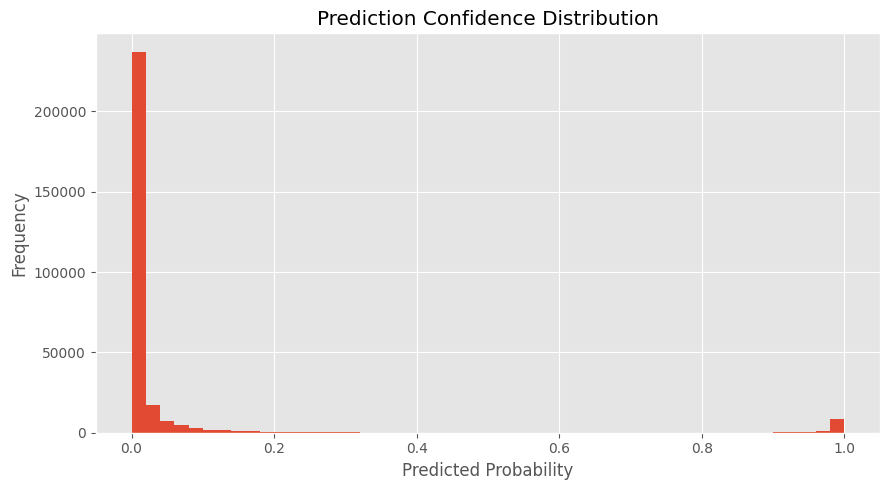

In [5]:
plt.figure(figsize=(9,5))

plt.hist(
    deployment["Probability"],
    bins=50
)

plt.xlabel("Predicted Probability")

plt.ylabel("Frequency")

plt.title("Prediction Confidence Distribution")

plt.tight_layout()

plt.savefig(
    FIGURE_PATH/"deployment_probability_distribution.png",
    dpi=300
)

plt.show()

In [6]:
deployment["Probability"].describe()

count    288344.000000
mean          0.049018
std           0.189711
min           0.000000
25%           0.000000
50%           0.000003
75%           0.007840
max           1.000000
Name: Probability, dtype: float64

In [7]:
deployment["Confidence"] = pd.cut(

    deployment["Probability"],

    bins=[0,0.6,0.8,0.95,1],

    labels=[
        "Low",
        "Medium",
        "High",
        "Very High"
    ]

)

deployment["Confidence"].value_counts()

Confidence
Low          144155
Very High      9759
High           1102
Medium          185
Name: count, dtype: int64

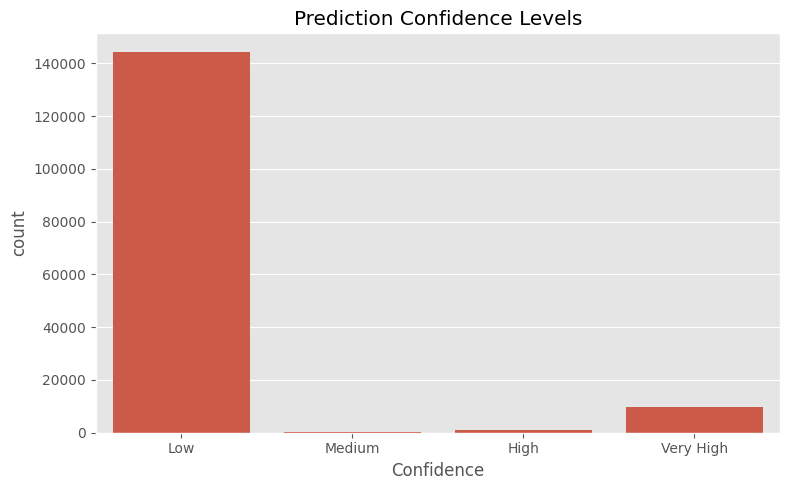

In [8]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=deployment,
    x="Confidence",
    order=[
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

plt.title("Prediction Confidence Levels")

plt.tight_layout()

plt.savefig(
    FIGURE_PATH/"confidence_levels.png",
    dpi=300
)

plt.show()

In [9]:
high_risk = deployment[

    deployment["Probability"]>0.95

]

high_risk.head()

,FIT101,LIT101,MV101,P101,P102,AIT201,AIT202,AIT203,FIT201,MV201,...,PIT502,PIT503,FIT601,P601,P602,P603,True,Prediction,Probability,Confidence
4,-1.565178,1.775168,-2.880775,-1.648125,-0.046608,-0.276842,1.313974,0.306767,-1.651437,-3.020295,...,-3.769375,-6.142788,-0.099023,0.0,-0.091453,0.0,1,1,1.000000,Very High
11,-1.565178,1.778652,-2.880775,-1.648125,-0.046608,-0.484649,1.606909,-0.378968,-1.651437,-3.020295,...,-3.769375,-6.135755,-0.099023,0.0,-0.091453,0.0,1,1,1.000000,Very High
23,0.540891,-0.749147,0.335952,0.606750,-0.046608,-0.420942,0.920683,-0.333524,0.603570,0.321655,...,-0.887695,0.062737,-0.099023,0.0,-0.091453,0.0,1,1,0.960217,Very High
66,-1.565178,1.778335,-2.880775,-1.648125,-0.046608,-0.208585,0.936960,0.598076,-1.651437,-3.020295,...,-3.769375,-6.151986,-0.099023,0.0,-0.091453,0.0,1,1,1.000000,Very High
122,0.636369,0.570022,0.335952,-1.648125,-0.046608,3.073867,0.055463,-0.483256,-1.651437,-3.020295,...,1.727161,0.083835,-0.098181,0.0,-0.091453,0.0,1,1,0.984006,Very High


In [10]:
print(

    f"High Risk Samples : {len(high_risk):,}"

)

High Risk Samples : 9,759


In [11]:
false_positive = deployment[

    (deployment["True"]==0)

    &

    (deployment["Prediction"]==1)

]

len(false_positive)

230

In [12]:
false_negative = deployment[

    (deployment["True"]==1)

    &

    (deployment["Prediction"]==0)

]

len(false_negative)

6

In [13]:
summary = pd.DataFrame({

    "Metric":[

        "Total Samples",

        "High Risk",

        "False Positive",

        "False Negative"

    ],

    "Value":[

        len(deployment),

        len(high_risk),

        len(false_positive),

        len(false_negative)

    ]

})

summary

,Metric,Value
0,Total Samples,288344
1,High Risk,9759
2,False Positive,230
3,False Negative,6


In [14]:
summary.to_csv(

    RESULT_PATH/"deployment_summary.csv",

    index=False

)

In [15]:
print("""

Deployment Assessment
----------------------

✔ Model successfully predicts industrial anomalies.

✔ Prediction confidence is available.

✔ High-risk events can be identified.

✔ False Positive and False Negative cases are monitored.

✔ Model is ready for deployment in an industrial monitoring pipeline.

""")



Deployment Assessment
----------------------

✔ Model successfully predicts industrial anomalies.

✔ Prediction confidence is available.

✔ High-risk events can be identified.

✔ False Positive and False Negative cases are monitored.

✔ Model is ready for deployment in an industrial monitoring pipeline.




In [16]:
deployment_score = {

    "Prediction Availability":True,

    "Probability Available":True,

    "Explainability":True,

    "Risk Categorization":True,

    "False Alarm Monitoring":True,

    "Deployment Ready":True

}

deployment_score

{'Prediction Availability': True,
 'Probability Available': True,
 'Explainability': True,
 'Risk Categorization': True,
 'False Alarm Monitoring': True,
 'Deployment Ready': True}

In [17]:
pd.DataFrame(

    deployment_score.items(),

    columns=[

        "Component",

        "Status"

    ]

).to_csv(

    RESULT_PATH/"deployment_checklist.csv",

    index=False

)

In [18]:
print("""
Notebook 16 Completed Successfully.

Outputs Generated:

deployment_probability_distribution.png

confidence_levels.png

deployment_summary.csv

deployment_checklist.csv

Industrial Deployment Assessment Completed.
""")


Notebook 16 Completed Successfully.

Outputs Generated:

deployment_probability_distribution.png

confidence_levels.png

deployment_summary.csv

deployment_checklist.csv

Industrial Deployment Assessment Completed.

